In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, KFold
from scipy import stats

In [2]:
mlb_pitchers = pd.read_csv('All Pitchers Cleaned.csv')
mlb_pitchers

,Player,Debut Year,Debut Age,Retirement Year,Retirement Age,Career Length,Wins,Losses,Win Percentage,Total Decisions,...,BF,ERA+,FIP,WHIP,H9,HR9,BB9,SO9,SO/BB,Hall of Fame
0,Cy Young,1890,23,1911,44,21,511,315,0.619,826,...,29565,138,2.84,1.130,8.7,0.2,1.5,3.4,2.30,1
1,Pud Galvin,1875,18,1892,35,17,365,310,0.541,675,...,25415,107,2.96,1.191,9.6,0.2,1.1,2.7,2.43,1
2,Walter Johnson,1907,19,1927,39,20,417,279,0.599,696,...,23415,147,2.38,1.061,7.5,0.1,2.1,5.3,2.57,1
3,Phil Niekro,1964,25,1987,48,23,318,274,0.537,592,...,22677,115,3.62,1.268,8.4,0.8,3.0,5.6,1.85,1
4,Nolan Ryan,1966,19,1993,46,27,324,292,0.526,616,...,22575,112,2.97,1.247,6.6,0.5,4.7,9.5,2.04,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1210,Charlie Robertson,1919,23,1928,32,9,49,80,0.380,129,...,4453,90,3.89,1.518,10.3,0.3,3.4,2.8,0.82,0
1211,Sammy Ellis,1962,21,1969,28,7,63,58,0.521,121,...,4296,88,3.90,1.340,8.7,1.1,3.4,6.1,1.79,0
1212,Lil Stoner,1922,23,1931,32,9,50,57,0.467,107,...,4466,87,4.13,1.548,10.6,0.6,3.4,2.7,0.80,0
1213,Johnny Humphries,1938,23,1946,31,8,52,63,0.452,115,...,4342,97,3.80,1.394,9.2,0.4,3.4,2.8,0.85,0


In [5]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.models import Sequential
model = Sequential()

In [7]:
(X_train, y_train), (X_test, y_test) = mlb_pitchers

AttributeError: 'DataFrame' object has no attribute 'load_data'

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [9]:
# Features
X = mlb_pitchers.drop(columns=['Hall of Fame', 'Player'])

# Target
y = mlb_pitchers['Hall of Fame']

In [11]:
numerical_features = mlb_pitchers.select_dtypes(include=np.number)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
    ])

In [13]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

NameError: name 'X_processed' is not defined

# New

In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [16]:
# Features
X = mlb_pitchers.drop(columns=['Hall of Fame', 'Player'])

# Target
y = mlb_pitchers['Hall of Fame']

# Convert to numpy arrays
X = X.values
y = y.values

In [17]:
def build_model(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')  # binary classification
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [18]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# To store out-of-fold predictions
oof_preds = np.zeros(len(X))
oof_actuals = np.zeros(len(X))

In [19]:
for fold, (train_idx, test_idx) in enumerate(kf.split(X, y)):
    print(f"Training fold {fold + 1}...")
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Build and train model
    model = build_model(input_dim=X_train.shape[1])
    model.fit(X_train, y_train, epochs=30, batch_size=16, verbose=0)
    
    # Predict on test fold
    preds = model.predict(X_test).ravel()
    
    # Store results
    oof_preds[test_idx] = preds
    oof_actuals[test_idx] = y_test

Training fold 1...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Training fold 2...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Training fold 3...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Training fold 4...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Training fold 5...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [20]:
from sklearn.metrics import roc_auc_score, accuracy_score

# Threshold for classification
pred_classes = (oof_preds >= 0.5).astype(int)

print("Overall Accuracy:", accuracy_score(oof_actuals, pred_classes))
print("Overall ROC AUC:", roc_auc_score(oof_actuals, oof_preds))


Overall Accuracy: 0.9654320987654321
Overall ROC AUC: 0.9807224506490431


In [22]:
nn_cv_results = pd.DataFrame()
nn_cv_results['Player'] = mlb_pitchers['Player']
nn_cv_results['Hall of Fame'] = y
nn_cv_results['Prediction'] = pred_classes
nn_cv_results['Prediction Correct'] = (nn_cv_results['Hall of Fame'] == nn_cv_results['Prediction']).astype(int)
nn_cv_results['Prediction Confidence'] = oof_preds
nn_cv_results

,Player,Hall of Fame,Prediction,Prediction Correct,Prediction Confidence
0,Cy Young,1,1,1,9.999929e-01
1,Pud Galvin,1,1,1,7.244584e-01
2,Walter Johnson,1,1,1,9.994264e-01
3,Phil Niekro,1,1,1,9.310621e-01
4,Nolan Ryan,1,1,1,9.081260e-01
...,...,...,...,...,...
1210,Charlie Robertson,0,0,1,3.743188e-17
1211,Sammy Ellis,0,0,1,5.523518e-11
1212,Lil Stoner,0,0,1,1.114777e-14
1213,Johnny Humphries,0,0,1,3.473219e-13


In [23]:
nn_cv_results['Prediction Correct'].value_counts()

Prediction Correct
1    1173
0      42
Name: count, dtype: int64

In [24]:
# Run this cell after your neural network cross-validation loop

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, precision_recall_curve, roc_curve, auc, f1_score
)

def show_summary_report(actual, prediction):
    """
    Generates a detailed classification report with metrics, confusion matrix,
    precision-recall curve, and ROC curve. Works with neural network probability outputs.
    """

    # Ensure numpy arrays
    if isinstance(actual, pd.Series):
        actual = actual.values.astype(int)
    prediction = np.array(prediction).astype(float)

    # Convert probabilities to binary predictions (threshold = 0.5)
    prediction_int = (prediction >= 0.5).astype(int)

    print('Accuracy : %.4f [TP / N]         Best: 1, Worst: 0' %
          accuracy_score(actual, prediction_int))
    print('           Percentage of all predictions that were correct.')

    print('Precision: %.4f [TP / (TP + FP)] Best: 1, Worst: 0' %
          precision_score(actual, prediction_int))
    print('           Percent of Positive predictions that were correct. Minimizes false positives.')

    print('Recall   : %.4f [TP / (TP + FN)] Best: 1, Worst: 0' %
          recall_score(actual, prediction_int))
    print('           Percent of True instances that were identified as such. Minimizes false negatives.')

    print('F1 Score : %.4f [(2 * P * R) / (P + R)]  Best: 1, Worst: 0' %
          f1_score(actual, prediction_int))
    print('           Harmonic mean of Precision and Recall.\n           Finds a balance in minimizing both false positives and false negatives.')

    # ROC AUC can handle probabilities
    try:
        roc_auc = roc_auc_score(actual, prediction)
        print('ROC AUC  : %.4f                  Best: 1, Worst: < 0.5' % roc_auc)
    except ValueError:
        print('ROC AUC  : Undefined (only one class present in y_true or y_score)')

    print('-' * 80)
    print('TP: True Positives, FP: False Positives,')
    print('TN: True Negatives, FN: False Negatives,')
    print('N: Number of samples')

    # Confusion Matrix
    mat = confusion_matrix(actual, prediction_int, labels=[0, 1])

    # Precision/Recall Curve
    precision, recall, _ = precision_recall_curve(actual, prediction)

    # ROC Curve
    fpr, tpr, _ = roc_curve(actual, prediction)
    roc_auc = auc(fpr, tpr)

    # Plot visuals
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    fig.subplots_adjust(left=0.02, right=0.98, wspace=0.2)

    # Confusion Matrix
    sns.heatmap(mat, square=True, annot=True, fmt='d', cbar=False,
                cmap='Greens', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted label')
    ax[0].set_ylabel('True label')

    # Precision-Recall Curve
    step_kwargs = {'step': 'post'}
    ax[1].step(recall, precision, color='r', alpha=0.2, where='post')
    ax[1].fill_between(recall, precision, alpha=0.2, color='r', **step_kwargs)
    ax[1].set_ylim([0.0, 1.0])
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].set_title('2-class Precision-Recall curve')

    # ROC Curve
    ax[2].plot(fpr, tpr, color='darkorange', lw=2,
               label='ROC curve (AUC = %0.2f)' % roc_auc)
    ax[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[2].set_xlim([0.0, 1.0])
    ax[2].set_ylim([0.0, 1.0])
    ax[2].set_xlabel('False Positive Rate')
    ax[2].set_ylabel('True Positive Rate')
    ax[2].set_title('Receiver Operating Characteristic')
    ax[2].legend(loc='lower right')

    plt.show()


Accuracy : 0.9654 [TP / N]         Best: 1, Worst: 0
           Percentage of all predictions that were correct.
Precision: 0.7778 [TP / (TP + FP)] Best: 1, Worst: 0
           Percent of Positive predictions that were correct. Minimizes false positives.
Recall   : 0.6829 [TP / (TP + FN)] Best: 1, Worst: 0
           Percent of True instances that were identified as such. Minimizes false negatives.
F1 Score : 0.7273 [(2 * P * R) / (P + R)]  Best: 1, Worst: 0
           Harmonic mean of Precision and Recall.
           Finds a balance in minimizing both false positives and false negatives.
ROC AUC  : 0.9807                  Best: 1, Worst: < 0.5
--------------------------------------------------------------------------------
TP: True Positives, FP: False Positives,
TN: True Negatives, FN: False Negatives,
N: Number of samples


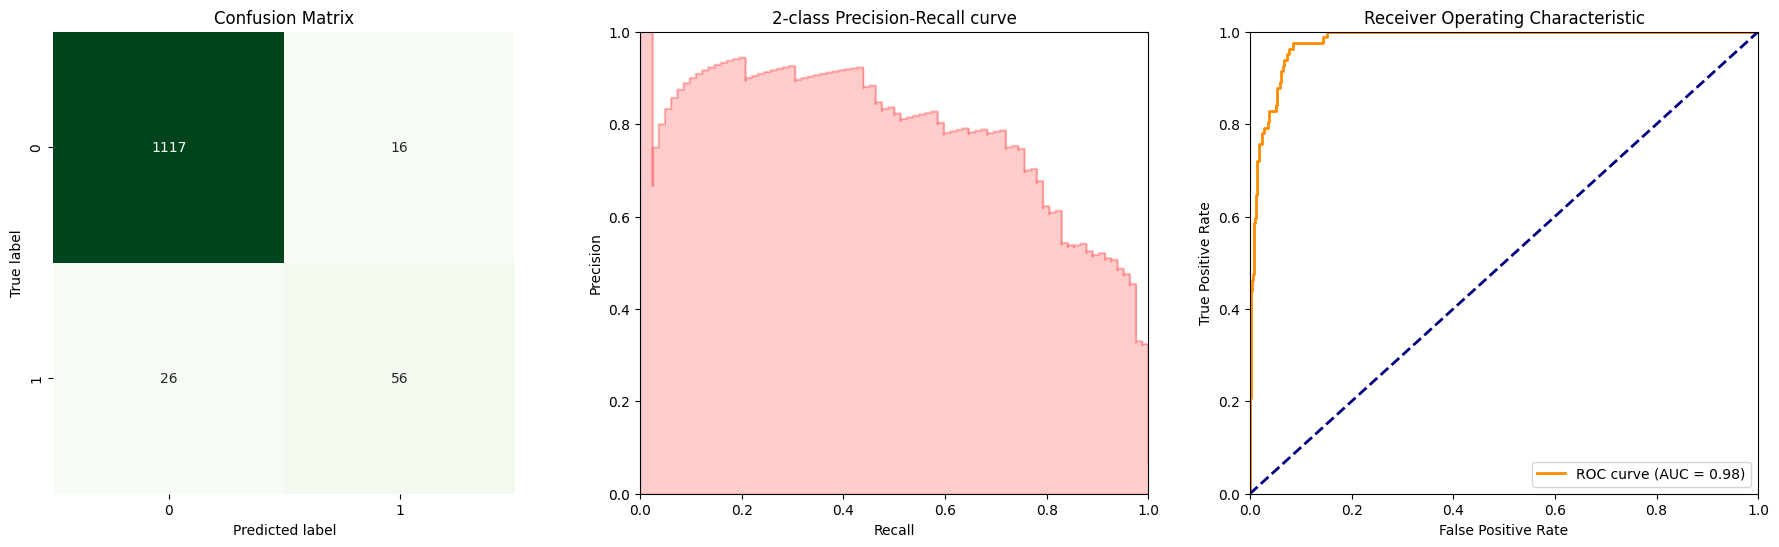

In [25]:
show_summary_report(oof_actuals, oof_preds)
